# Augmentations

Segmentation mask augmentations. The downsampled mask target (`y.npy`, shape `(out_h, out_w)`, float32 in `[0, 1]`) is used verbatim as the training label today. In practice the mask doesn't need to be pixel-precise: a `1` can be `0.9`, a `0` can be `0.05`, and edges don't need to be razor sharp. This notebook builds three candidate augmentations for that mask and visualizes each against the original, with a diff panel to make the change obvious.

In [1]:
import sys
sys.path.insert(0, '/home/ethantu/workspace/good-vibrations/src')

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from scipy.ndimage import gaussian_filter


## 0. Load a sample

Point `SAMPLE_DIR` at any sample directory (e.g. `data/samples/000000`). The mask we
augment is `y.npy`, the downsampled `(out_h, out_w)` float32 target in `[0, 1]` — this is
exactly the tensor that gets fed to the model as `mask_true`, so any augmentation we
settle on here plugs directly into the training dataloader.


In [2]:
SAMPLE_DIR = Path('/home/ethantu/workspace/good-vibrations/data/samples/000000')

mask = np.load(SAMPLE_DIR / 'y.npy').astype(np.float32)
print(f'mask shape={mask.shape} dtype={mask.dtype} min={mask.min():.3f} max={mask.max():.3f}')


mask shape=(18, 44) dtype=float32 min=0.000 max=1.000


## 1. Four augmentation methods

- **`label_smooth`** — deterministic value remap. Squashes the whole `[0, 1]` range into
  `[lo, hi]` (e.g. `1 → 0.9`, `0 → 0.05`), uniformly, everywhere. No spatial component:
  a flat interior region gets flattened toward `hi`/`lo` just like an edge pixel does.
- **`edge_blur`** — deterministic spatial smoothing (`scipy.ndimage.gaussian_filter`).
  Leaves flat interior/exterior regions untouched (blurring a constant region is a no-op)
  but softens the transition band right at the boundary, which is the "edges don't need
  to be razor sharp" behavior specifically.
- **`random_boundary_jitter`** — stochastic, meant to be called fresh per training step.
  Randomly dilates or erodes the boundary by a sub-pixel amount (so the object's apparent
  size/position jitters slightly, simulating real segmentation-boundary uncertainty), then
  applies a random-strength blur and random-strength label smoothing on top. Combines the
  first two ideas with per-call randomness rather than a single fixed transform.
- **`noisy_blur`** — Gaussian-blurs the mask, then, restricted to the pixels that were
  non-zero *before* blurring (i.e. inside the original object footprint, not the
  background), adds small Gaussian noise (`N(0, noise_std)`). This perturbs the object's
  interior/edge values with per-pixel noise on top of the blur, while leaving pixels that
  started at exactly `0` alone (aside from what the blur itself bleeds into them).


In [3]:
def label_smooth(mask, lo=0.05, hi=0.9):
    """Deterministic value remap: [0, 1] -> [lo, hi], everywhere. No spatial effect."""
    return mask * (hi - lo) + lo


def edge_blur(mask, sigma=0.8):
    """Deterministic spatial smoothing with a fixed 3x3 kernel (radius=1). Softens the
    boundary transition band; flat interior/exterior regions are unaffected."""
    return gaussian_filter(mask, sigma=sigma, radius=1, mode='nearest')


def random_boundary_jitter(
    mask, rng,
    shift_range=1.0,       # max sub-pixel shift of the boundary, in mask pixels
    sigma_range=(0.4, 1.2),
    lo_range=(0.0, 0.08),
    hi_range=(0.85, 1.0),
):
    """Stochastic augmentation for use inside a training loop (call once per sample
    per epoch with a fresh `rng`). Jitters the boundary position by a random sub-pixel
    shift, blurs by a random amount (fixed 3x3 kernel), then applies a random
    label-smoothing range."""
    shift = rng.uniform(-shift_range, shift_range, size=2)
    jittered = ndimage.shift(mask, shift, order=1, mode='nearest')

    sigma = rng.uniform(*sigma_range)
    blurred = gaussian_filter(jittered, sigma=sigma, radius=1, mode='nearest')

    lo = rng.uniform(*lo_range)
    hi = rng.uniform(*hi_range)
    return np.clip(blurred, 0, 1) * (hi - lo) + lo

def noisy_blur(mask, rng, sigma=0.8, noise_std=0.05):
    """Gaussian blur (fixed 3x3 kernel), then add small Gaussian noise back to the
    original non-zero pixels."""
    blurred = gaussian_filter(mask, sigma=sigma, radius=1, mode='nearest')
    noise = rng.normal(loc=0.0, scale=noise_std, size=mask.shape)
    out = blurred.copy()
    out[mask != 0] += noise[mask != 0]
    return np.clip(out, 0, 1)


## 2. Compare against the original

Top row: mask values (shared grayscale scale, `0`→black, `1`→white). Bottom row: the
diff vs. the original mask, on a diverging red/blue scale centered at `0` — blue means
"pushed up", red means "pushed down" — so the effect of each augmentation is obvious at
a glance instead of having to eyeball two grayscale panels against each other.


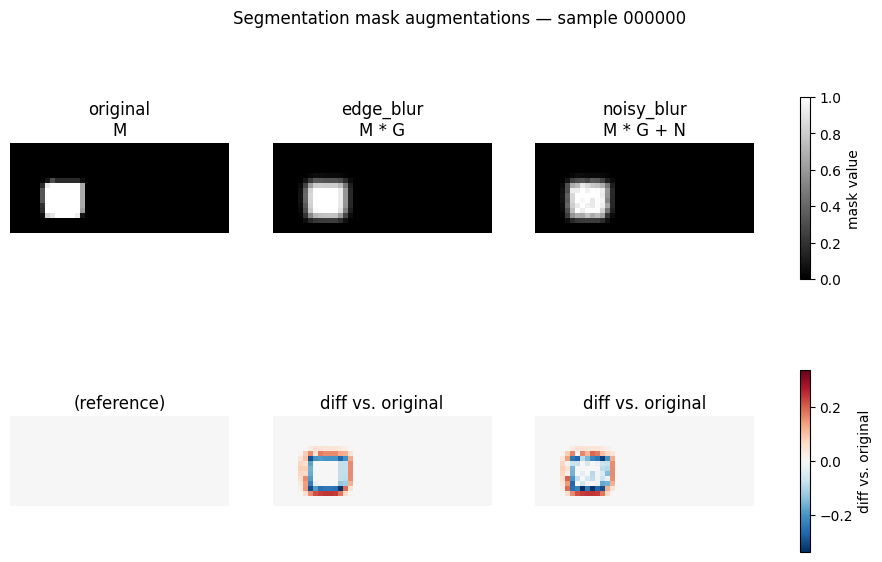

In [4]:
rng = np.random.default_rng(0)  # fixed seed so the demo plot is reproducible

variants = {
    'original': mask,
    # 'label_smooth': label_smooth(mask),
    'edge_blur': edge_blur(mask),
    # 'random_boundary_jitter': random_boundary_jitter(mask, rng),
    'noisy_blur': noisy_blur(mask, rng),
}

eqns = {'original': 'M', 'edge_blur': 'M * G', 'noisy_blur': 'M * G + N'}

diff_max = max(np.abs(v - mask).max() for v in variants.values()) or 1e-6

fig, axes = plt.subplots(2, len(variants), figsize=(4 * len(variants), 6.5))

for col, (name, v) in enumerate(variants.items()):
    ax_val, ax_diff = axes[0, col], axes[1, col]

    im_val = ax_val.imshow(v, cmap='gray', vmin=0, vmax=1)
    ax_val.set_title(name + f"\n{eqns[name]}")
    ax_val.axis('off')

    diff = v - mask
    im_diff = ax_diff.imshow(diff, cmap='RdBu_r', vmin=-diff_max, vmax=diff_max)
    ax_diff.set_title('diff vs. original' if col > 0 else '(reference)')
    ax_diff.axis('off')

fig.colorbar(im_val, ax=axes[0, :].tolist(), shrink=0.8, label='mask value')
fig.colorbar(im_diff, ax=axes[1, :].tolist(), shrink=0.8, label='diff vs. original')
fig.suptitle(f'Segmentation mask augmentations — sample {SAMPLE_DIR.name}')
plt.show()


## 3. Value distribution before/after

Confirms numerically what the diff panels show visually: `label_smooth` compresses the
whole histogram into `[lo, hi]`; `edge_blur` only pulls the boundary pixels off `{0, 1}`
and leaves the bulk of the mass at the extremes; `random_boundary_jitter` does a bit of
both.


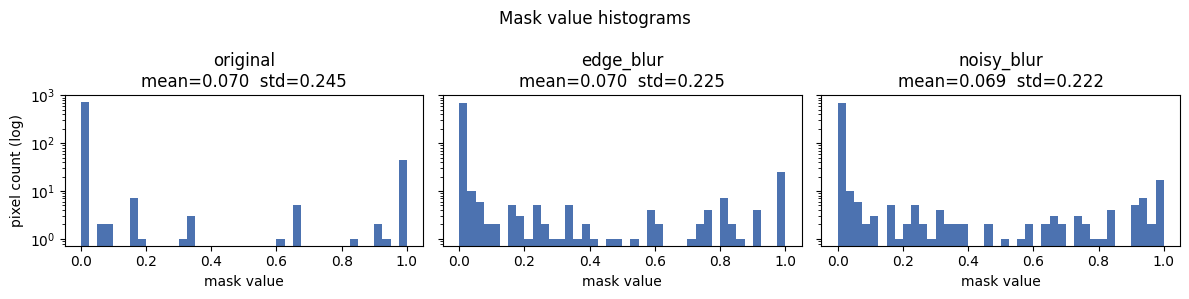

original                 min=0.000  max=1.000  mean=0.070  std=0.245
edge_blur                min=0.000  max=1.000  mean=0.070  std=0.225
noisy_blur               min=0.000  max=1.000  mean=0.069  std=0.222


In [5]:
fig, axes = plt.subplots(1, len(variants), figsize=(4 * len(variants), 3), sharey=True)

bins = np.linspace(0, 1, 41)
for ax, (name, v) in zip(axes, variants.items()):
    ax.hist(v.ravel(), bins=bins, color='#4C72B0')
    ax.set_yscale('log')
    ax.set_title(f'{name}\nmean={v.mean():.3f}  std={v.std():.3f}')
    ax.set_xlabel('mask value')
axes[0].set_ylabel('pixel count (log)')
fig.suptitle('Mask value histograms')
plt.tight_layout()
plt.show()

for name, v in variants.items():
    print(f'{name:24s} min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}  std={v.std():.3f}')


## 4. Frequency-domain augmentation (clean FFT)

Separate from the mask augmentations above: this multiplies the sample's **clean FFT
spectrum** (`inputs/03_fft_shifts.npz`, complex, shape `(position, freq, channel)`) by a
smooth, random, per-frequency gain curve `G(f)` — simulating the kind of gentle
frequency-response variation (mic/speaker placement, distance, room acoustics) that
differs between recordings.

`G(f)` is built by picking a handful of random gain values at a few control frequencies
and connecting them with a monotonic cubic spline (`scipy.interpolate.PchipInterpolator`),
then rescaling the result into a fixed band (default `[0.8, 1.2]`) so it's always a mild,
smooth perturbation — never a sharp notch or a large amplification. This is a much
simpler version of the same idea as the original `hermit_poly`/`interp` torch code: same
"smooth random curve through a few control points," but using scipy's spline instead of a
hand-rolled Hermite basis + manual `fftfreq`/`searchsorted` bookkeeping.


In [6]:
from scipy.interpolate import PchipInterpolator

fft_npz = np.load(SAMPLE_DIR / 'inputs' / '03_fft_shifts.npz')
clean_fft = fft_npz['fft'][0]   # (position, freq, channel) complex64
freqs = fft_npz['freqs']        # (freq,) Hz
print(f'clean_fft shape={clean_fft.shape} dtype={clean_fft.dtype}  freqs={freqs.min():.0f}-{freqs.max():.0f} Hz')


clean_fft shape=(100, 3421, 2) dtype=complex64  freqs=50-1000 Hz


In [7]:
def random_frequency_gain(freqs, rng, n_control=5, gain_range=(0.8, 1.2)):
    """Smooth random multiplicative gain curve G(f): random values at a few control
    frequencies, connected with a monotonic cubic spline, rescaled into gain_range."""
    control_freqs = np.linspace(freqs.min(), freqs.max(), n_control)
    control_gains = rng.normal(loc=1.0, scale=1.0, size=n_control)

    spline = PchipInterpolator(control_freqs, control_gains)
    gain = spline(freqs)
    gain = (gain - gain.min()) / (gain.max() - gain.min())  # -> [0, 1]
    lo, hi = gain_range
    return (gain * (hi - lo) + lo).astype(np.float32)


def frequency_augmentation(clean_fft, freqs, rng, **kwargs):
    """Applies a random smooth per-frequency gain curve to a (position, freq, channel)
    complex FFT array. Returns (augmented_fft, gain)."""
    gain = random_frequency_gain(freqs, rng, **kwargs)
    return clean_fft * gain[None, :, None], gain


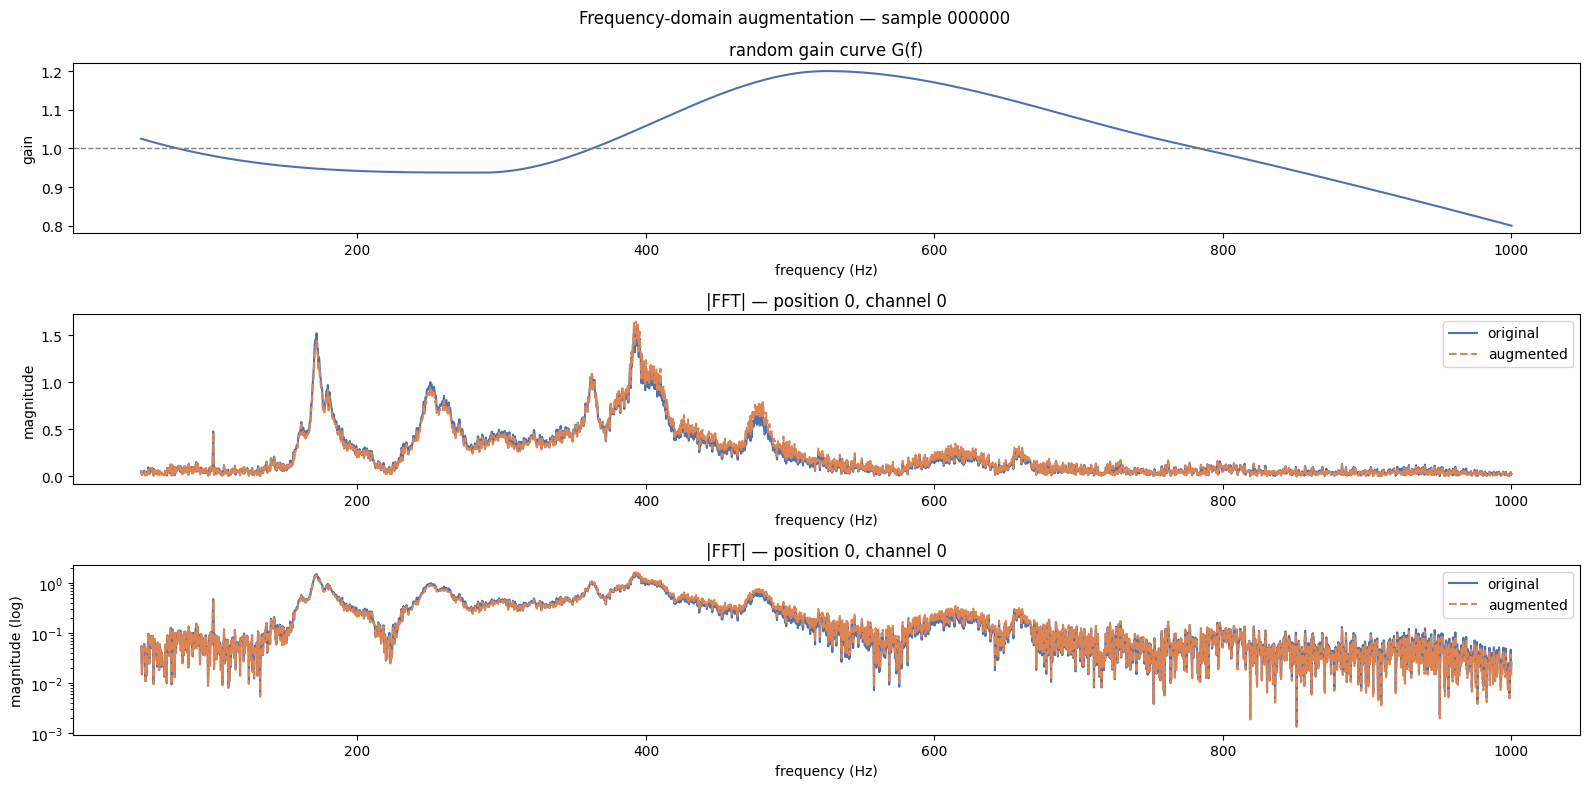

In [8]:
fft_rng = np.random.default_rng(0)  # fixed seed so the demo plot is reproducible

augmented_fft, gain = frequency_augmentation(clean_fft, freqs, fft_rng)

POSITION, CHANNEL = 0, 0
orig_mag = np.abs(clean_fft[POSITION, :, CHANNEL])
aug_mag = np.abs(augmented_fft[POSITION, :, CHANNEL])

fig, axes = plt.subplots(3, 1, figsize=(16, 8))

axes[0].plot(freqs, gain, color='#4C72B0')
axes[0].axhline(1.0, color='gray', linewidth=1, linestyle='--')
axes[0].set_title('random gain curve G(f)')
axes[0].set_xlabel('frequency (Hz)')
axes[0].set_ylabel('gain')

axes[1].plot(freqs, orig_mag, label='original', color='#4C72B0')
axes[1].plot(freqs, aug_mag, label='augmented', color='#DD8452', linestyle='--')
axes[1].set_title(f'|FFT| — position {POSITION}, channel {CHANNEL}')
axes[1].set_xlabel('frequency (Hz)')
axes[1].set_ylabel('magnitude')
axes[1].legend()

axes[2].plot(freqs, orig_mag, label='original', color='#4C72B0')
axes[2].plot(freqs, aug_mag, label='augmented', color='#DD8452', linestyle='--')
axes[2].set_yscale('log')
axes[2].set_title(f'|FFT| — position {POSITION}, channel {CHANNEL}')
axes[2].set_xlabel('frequency (Hz)')
axes[2].set_ylabel('magnitude (log)')
axes[2].legend()

fig.suptitle(f'Frequency-domain augmentation — sample {SAMPLE_DIR.name}')
plt.tight_layout()
plt.show()


## 5. Original torch/Hermite implementation, for comparison

This is your original `hermit_poly`/`interp` code, ported as-is (no scipy) and applied to
this sample's real `freqs` bins instead of a hand-built `fftfreq` domain, so it's directly
comparable to the scipy (`PchipInterpolator`) version above — same control points, same
`gain_range`, same seed.


In [9]:
import torch


def hermit_poly(t):
    tt = t[None, :] ** torch.arange(4, device=t.device)[:, None]
    A = torch.tensor([
        [1, 0, -3, 2],
        [0, 1, -2, 1],
        [0, 0, 3, -2],
        [0, 0, -1, 1]
    ], dtype=t.dtype, device=t.device)
    return A @ tt


def interp(x, y, xs):
    m = (y[1:] - y[:-1]) / (x[1:] - x[:-1])
    m = torch.cat([m[[0]], (m[1:] + m[:-1]) / 2, m[[-1]]])
    idxs = torch.searchsorted(x[1:], xs)
    dx = (x[idxs + 1] - x[idxs])
    hh = hermit_poly((xs - x[idxs]) / dx)
    return hh[0] * y[idxs] + hh[1] * m[idxs] * dx + hh[2] * y[idxs + 1] + hh[3] * m[idxs + 1] * dx


def frequency_augmentation_torch(freqs, seed, n_control=5, gain_range=(0.8, 1.2)):
    """Original hermit_poly/interp code, applied directly to this sample's real
    freq bins (instead of rebuilding a frequency axis via fftfreq + nearest-neighbor
    remap, since we already have the exact bins from the FFT we're augmenting)."""
    dtype = torch.float64
    generator = torch.Generator().manual_seed(seed)

    freqs_t = torch.tensor(freqs, dtype=dtype)
    x_points = torch.linspace(freqs_t.min(), freqs_t.max(), n_control, dtype=dtype)
    y_points = torch.normal(mean=1.0, std=1.0, size=(n_control,), generator=generator, dtype=dtype)

    values = interp(x_points, y_points, freqs_t)
    values = (values - values.min()) / (values.max() - values.min())

    lo, hi = gain_range
    G = values * (hi - lo) + lo
    return G.numpy().astype(np.float32)


/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


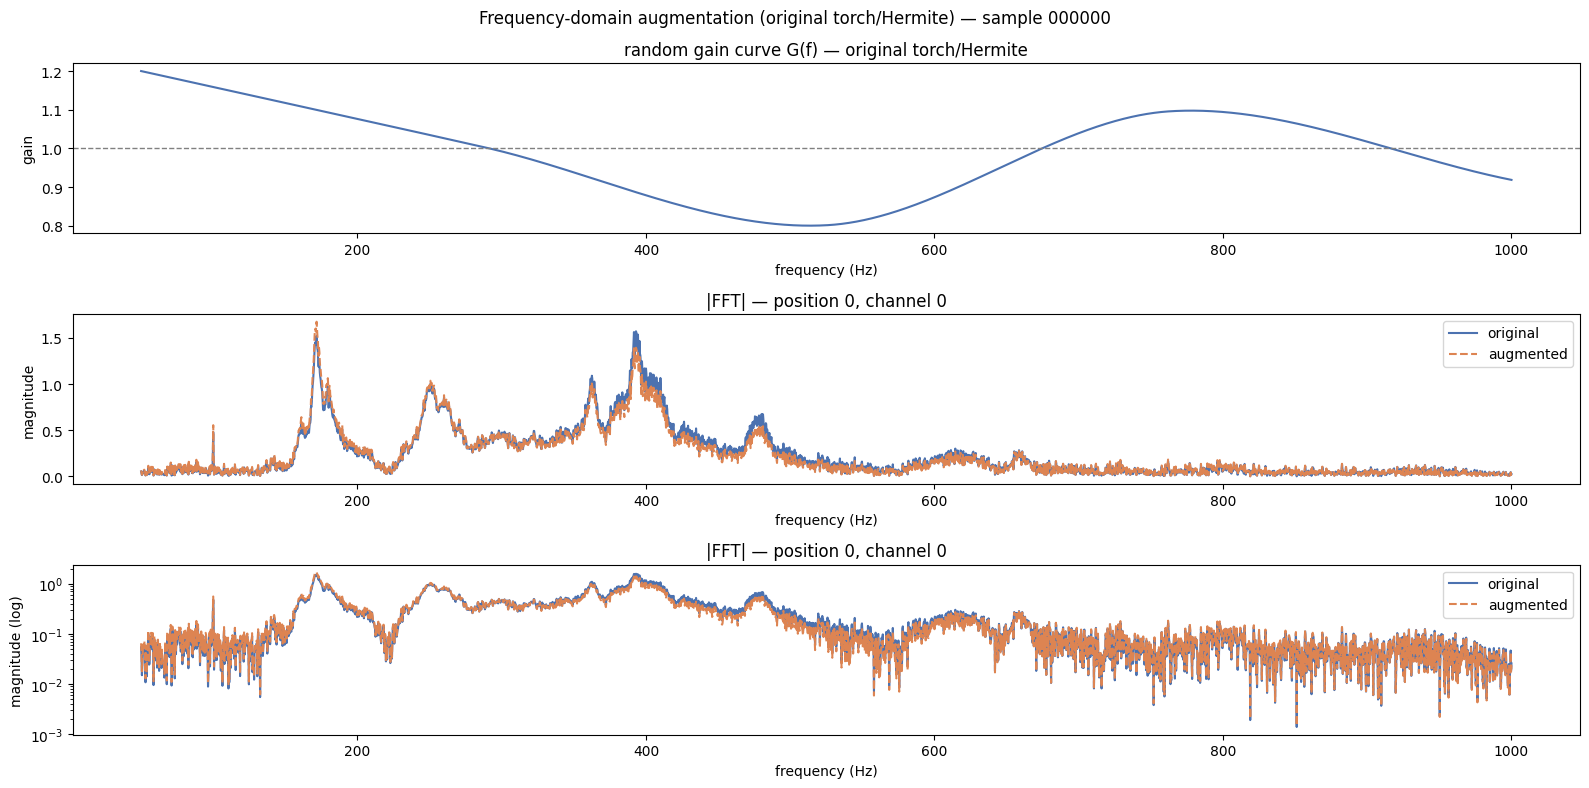

In [10]:
gain_torch = frequency_augmentation_torch(freqs, seed=0)
aug_fft_torch = clean_fft * gain_torch[None, :, None]
aug_mag_torch = np.abs(aug_fft_torch[POSITION, :, CHANNEL])

fig, axes = plt.subplots(3, 1, figsize=(16, 8))

axes[0].plot(freqs, gain_torch, color='#4C72B0')
axes[0].axhline(1.0, color='gray', linewidth=1, linestyle='--')
axes[0].set_title('random gain curve G(f) — original torch/Hermite')
axes[0].set_xlabel('frequency (Hz)')
axes[0].set_ylabel('gain')

axes[1].plot(freqs, orig_mag, label='original', color='#4C72B0')
axes[1].plot(freqs, aug_mag_torch, label='augmented', color='#DD8452', linestyle='--')
axes[1].set_title(f'|FFT| — position {POSITION}, channel {CHANNEL}')
axes[1].set_xlabel('frequency (Hz)')
axes[1].set_ylabel('magnitude')
axes[1].legend()

axes[2].plot(freqs, orig_mag, label='original', color='#4C72B0')
axes[2].plot(freqs, aug_mag_torch, label='augmented', color='#DD8452', linestyle='--')
axes[2].set_yscale('log')
axes[2].set_title(f'|FFT| — position {POSITION}, channel {CHANNEL}')
axes[2].set_xlabel('frequency (Hz)')
axes[2].set_ylabel('magnitude (log)')
axes[2].legend()

fig.suptitle(f'Frequency-domain augmentation (original torch/Hermite) — sample {SAMPLE_DIR.name}')
plt.tight_layout()
plt.show()


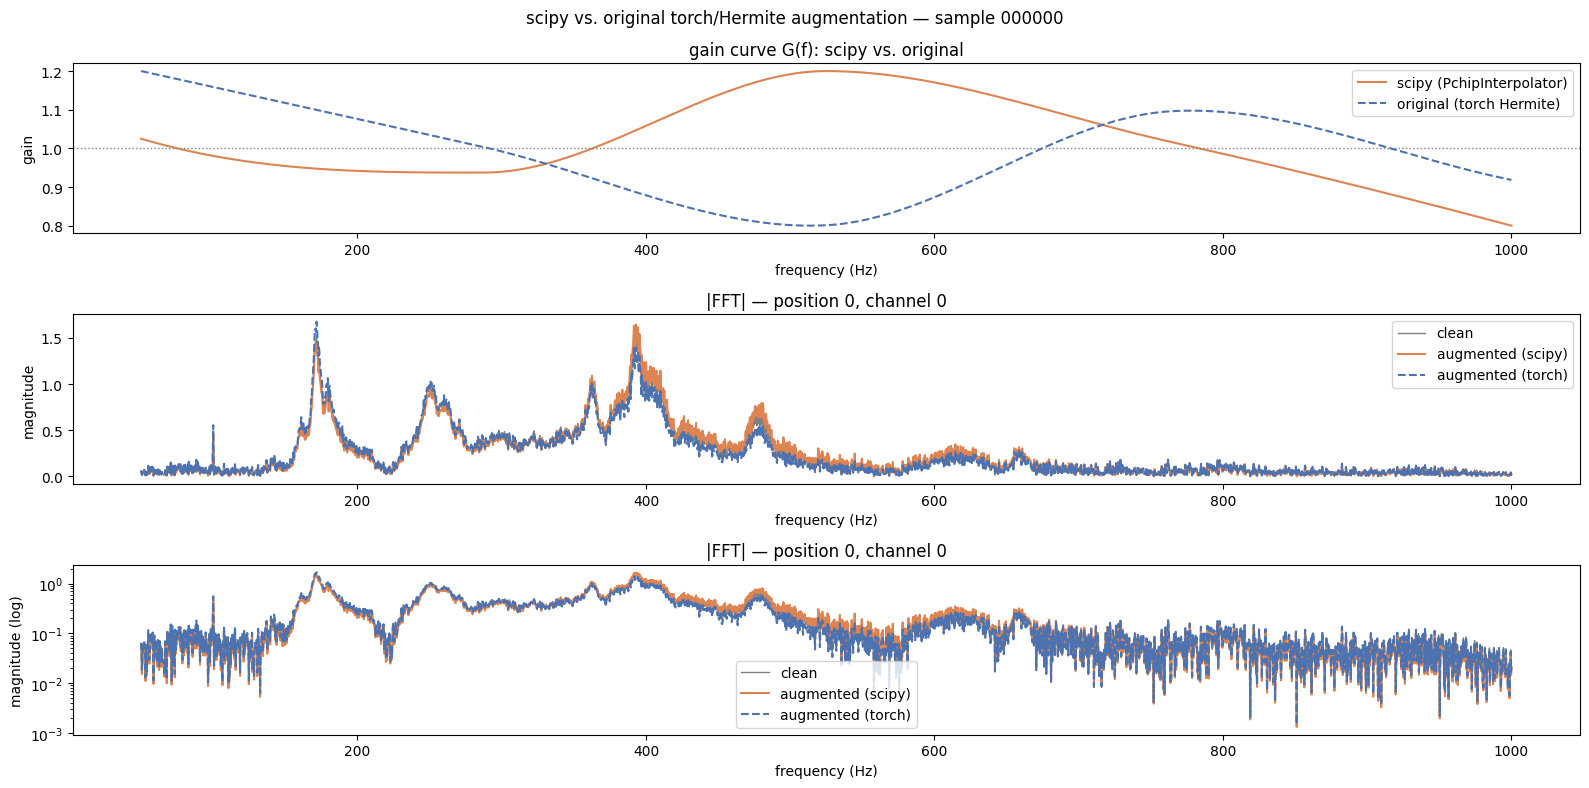

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 8))

axes[0].plot(freqs, gain, label='scipy (PchipInterpolator)', color='#DD8452')
axes[0].plot(freqs, gain_torch, label='original (torch Hermite)', color='#4C72B0', linestyle='--')
axes[0].axhline(1.0, color='gray', linewidth=1, linestyle=':')
axes[0].set_title('gain curve G(f): scipy vs. original')
axes[0].set_xlabel('frequency (Hz)')
axes[0].set_ylabel('gain')
axes[0].legend()

axes[1].plot(freqs, orig_mag, label='clean', color='gray', linewidth=1)
axes[1].plot(freqs, aug_mag, label='augmented (scipy)', color='#DD8452')
axes[1].plot(freqs, aug_mag_torch, label='augmented (torch)', color='#4C72B0', linestyle='--')
axes[1].set_title(f'|FFT| — position {POSITION}, channel {CHANNEL}')
axes[1].set_xlabel('frequency (Hz)')
axes[1].set_ylabel('magnitude')
axes[1].legend()

axes[2].plot(freqs, orig_mag, label='clean', color='gray', linewidth=1)
axes[2].plot(freqs, aug_mag, label='augmented (scipy)', color='#DD8452')
axes[2].plot(freqs, aug_mag_torch, label='augmented (torch)', color='#4C72B0', linestyle='--')
axes[2].set_yscale('log')
axes[2].set_title(f'|FFT| — position {POSITION}, channel {CHANNEL}')
axes[2].set_xlabel('frequency (Hz)')
axes[2].set_ylabel('magnitude (log)')
axes[2].legend()

fig.suptitle(f'scipy vs. original torch/Hermite augmentation — sample {SAMPLE_DIR.name}')
plt.tight_layout()
plt.show()
